# Lab 3

### Submission And Assignment Instructions
Submit your `Lab3_lastname_firstname.ipynb` file on canvas with your answers clearly marked (✅) and code commented. Skeleton code and/or comments are provided throughout to help you.

- ❓Questions you must answer or tasks are marked with a "❓"
- ✅ Answers you should give are marked with "✅ Answer:"
- *Helpful hints are usually given in italics*
- Code you need to write is marked with `##❓YOUR CODE HERE`
  - ⭐ Bonus questions are marked with a "⭐"
  - 🍓 Bonus answers are marked with a "🍓"

**Please don't erase ANY of these markings!** They're to help the TAs find your answers and code as much as they're to help you find the questions.

## Section 1: Proof of Non-negativity

❓Prove that non-negativity ($0 \leq D(\vec x, \vec y)$) follows from the three properties of a similarity metric. *You may do this math on paper and insert a picture of your work here.*

>> ✅Answer:![Problem11](Problem11.jpeg)

## Section 2: k-NN Visualizations with Toy Data

### 2.1: Visualizing Decision Boundaries
Run the code provided below to visualize the toy dataset and decision boundaries for several different distance metrics and values of $k$.

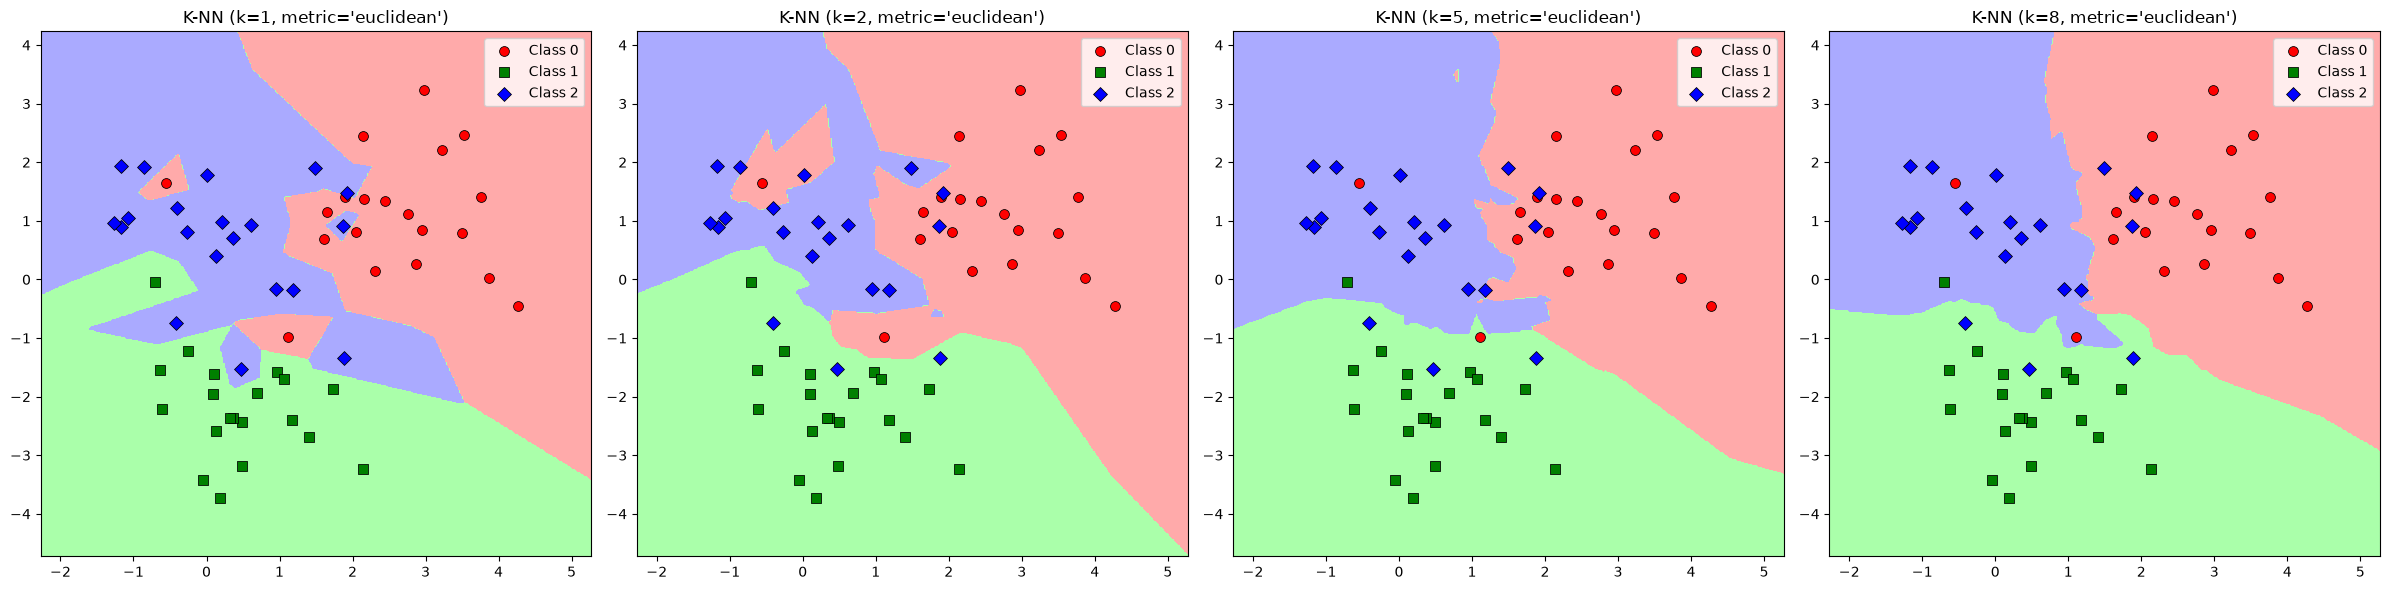

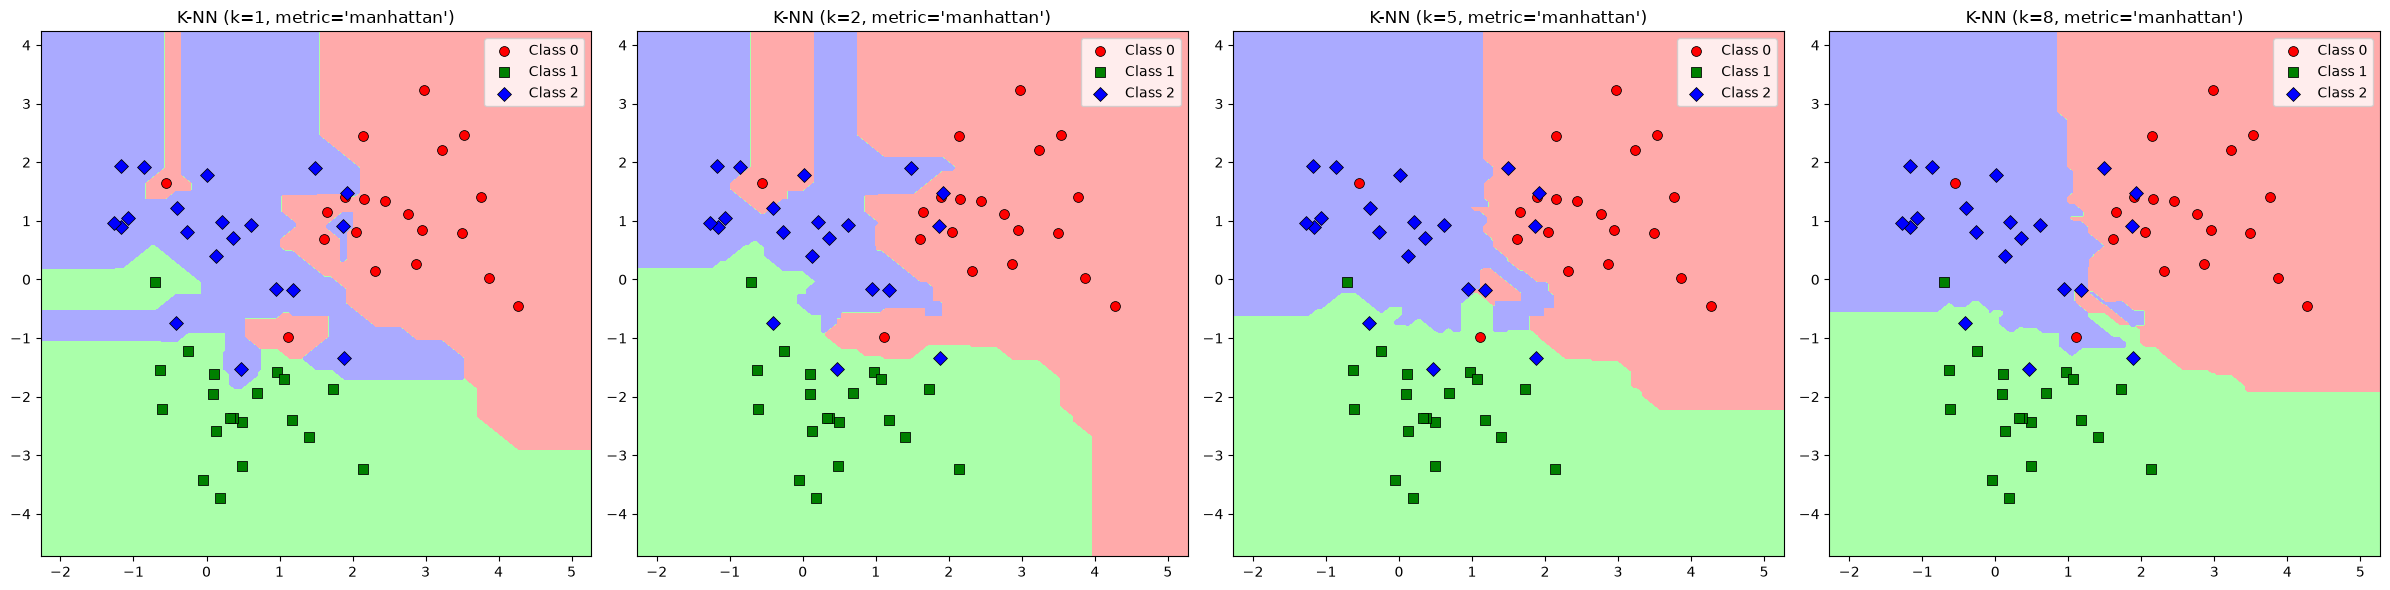

In [ ]:
## provided toy dataset code
# load necessary packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

# Generate toy dataset, set seed to ensure reproducibility
np.random.seed(0)
n_points_per_class = 20

# create 3 overlapping classes of data
class1 = np.random.randn(n_points_per_class, 2) + [2, 1]
class2 = np.random.randn(n_points_per_class, 2) + [1, -2]
class3 = np.random.randn(n_points_per_class, 2) + [0, 0]

# combine these points into X and y datasets
X = np.vstack((class1, class2, class3))
y = np.array([0] * n_points_per_class 
             + [1] * n_points_per_class 
             + [2] * n_points_per_class)

# Plotting function to show decision boundaries
def plot_decision_boundaries(X, y, metric, ks):
    n_cols = len(ks)
    fig, axes = plt.subplots(1, 
                             n_cols, 
                             figsize=(n_cols * 6, 6))

    cmap_light = ListedColormap(['#FFAAAA', 
                                 '#AAFFAA', 
                                 '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']
    markers = ['o', 's', 'D']

    for ax, k in zip(axes, ks):
        clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
        clf.fit(X, y)

        h = .02  # step size in the mesh (just for plotting decision boundaries)
        # prep plotting parameters for groups and decision boundaries
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ## plotting the outputs
        ax.contourf(xx, yy, Z, cmap=cmap_light)
        for i, color, marker in zip(range(3), cmap_bold, markers):
            sns.scatterplot(ax=ax, 
                            x=X[y == i, 0], 
                            y=X[y == i, 1], 
                            marker=marker, 
                            color=color,
                            edgecolor='k', 
                            s=50, 
                            label=f'Class {i}')

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        # make sure to label the plot with the metric and value of k
        ax.set_title(f"K-NN (k={k}, metric='{metric}')")
        ax.legend()

    plt.tight_layout()
    plt.show()

# Choose distance metrics and vector of values of k to display
metrics = ['euclidean', 'manhattan']
ks = [1, 2, 5, 8]

# call function to plot decision boundaries for different metrics and values of k side-by-side
for metric in metrics:
    plot_decision_boundaries(X, y, metric, ks)

❓2.1.1 Briefly describe similarities and differences between the different values of $k$ in the plots above. How do the decision boundaries change with different values of $k$? Based on your knowledge of how the data were generated in the code above, are particular values of $k$ more or less accurate classifiers?

✅ Answer: At k=1, each point's boundary follows its single nearest neighbor, producing jagged, highly localized decision regions that react to individual outliers. As k increases, boundaries smooth out because more neighbors are averaged into each decision with k=8 giving the smoothest boundaries. Since the three classes are Gaussian with overlapping tails, points near the overlapping region are ambiguous. A very low k tends to fit noise rather than class distribution, while a very high k blurs over the real structure near the cluster centers. A moderate k (2-5) is likely the more accurate classifier because it smooths over the noise without overdoing it.

❓2.1.2 Based on the way these data were generated in the code above, are there particular classes of data that should be more or less difficult to separate from the other(s)? Do you see that reflected in the plots and decision boundaries?

✅ Answer: Class 1 (centered at [2,1]) and Class 2 (centered at [1,-2]) are farther apart than either is from Class 3 (centered at [0,0]), which sits roughly between them. So Class 3 should be hardest to separate from the other two, while Class 1 and Class 2 should be easiest to separate from each other. The plots confirm this and show the boundary between Class 1 (red) and Class 2 (green) is pretty clean, while Class 3 (blue) shows the most misclassified/overlapping points, especially where it borders Class 1.

❓2.1.3 Using the same data and the same values of k, run the k-NN algorithm again using a cosine distance metric. *Hint: You should just have to call the `plot_decision_boundaries` function written above with slightly different parameters.*

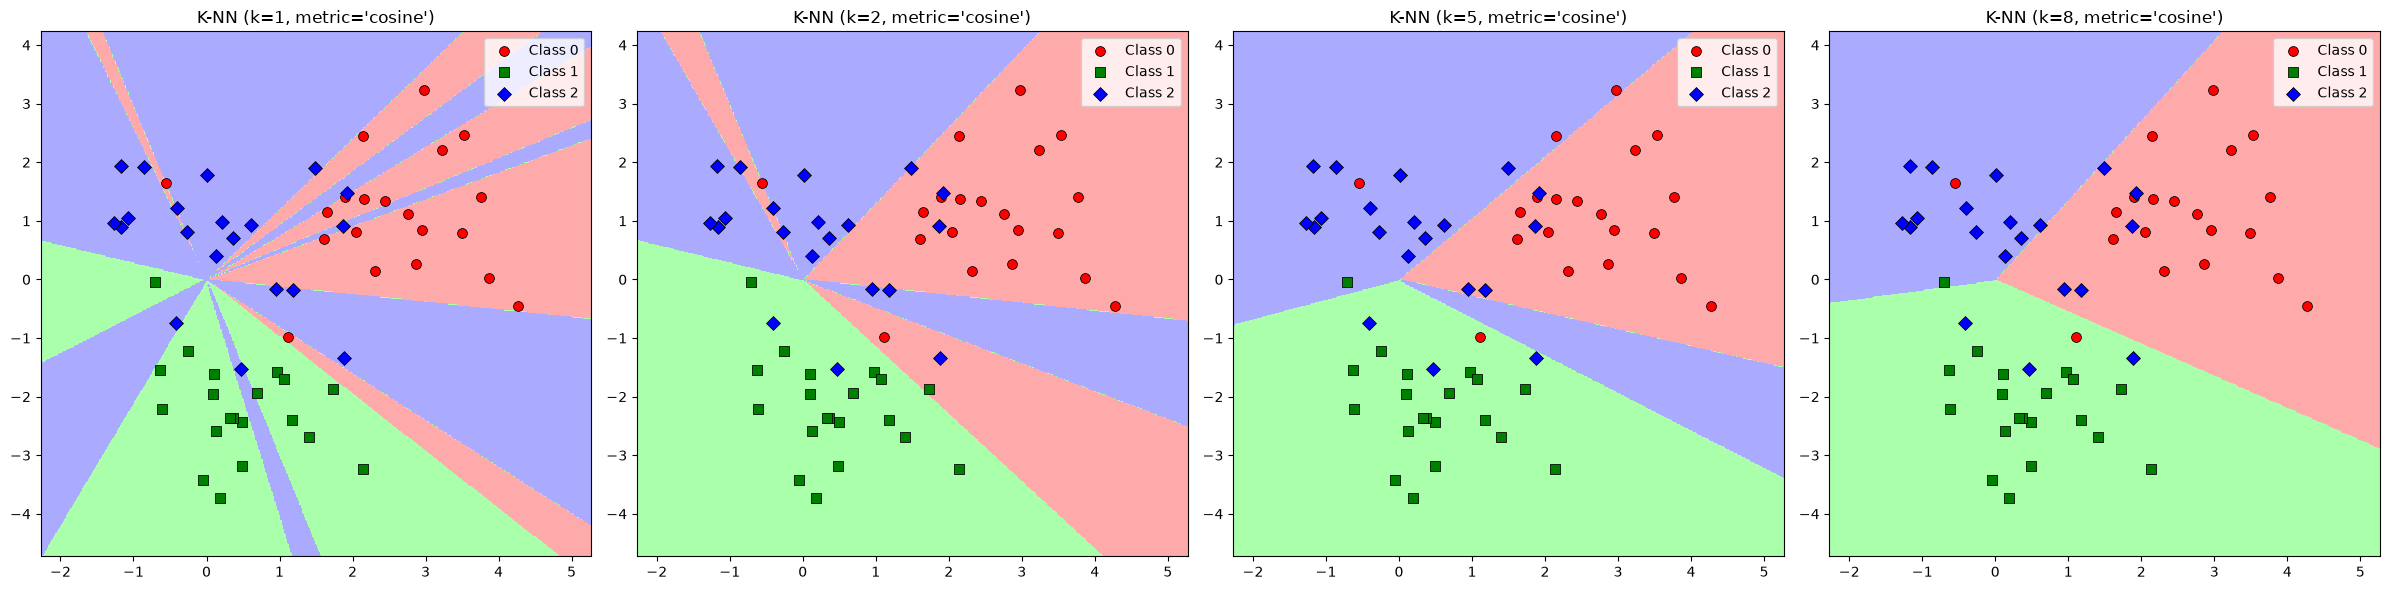

In [78]:
##❓YOUR CODE HERE
plot_decision_boundaries(X, y, metric = "cosine", ks=ks)

❓2.1.4 Cosine similarity can be thought to measure "directionality" of the data. What kind of errors occur for this data and cosine distance? Based on how the data was generated, why is this the case?

✅Answer: Cosine distance measures the angle between vectors from the origin, so points get grouped by direction not proximity. This causes errors near the origin, where small shifts in a point's location can change its angle dramatically and two points that are actually close together in Euclidean space can end up on opposite sides of a cosine-based decision boundary. Because all three class means have non-negative x-coordinates, most data lies in the same general "direction" from the origin, so cosine distance can't separate cleanly.

### 2.2: Splits & Cross-validation - choosing the best value of k

❓2.2.1 Choose an appropriate distance metric (*hint: not cosine similarity*) and add onto the code below to rerun the exercise above with cross-validation and test the vector of ks (`ks`) provided. Report the accuracy for each value of $k$ you test and create a plot of cross-validation accuracy vs. k. Add error bars for standard error of the mean to the cross-validation accuracy plots.

> A commented framework is provided below. Code blocks you need to complete are marked with `##❓YOUR CODE HERE` at the top.



In [79]:
## you don't need to modify this code block, just read it
## some newly necessary packages for cross-validation and error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score

# Generate toy dataset
np.random.seed(0)
n_points_per_class = 50

class1 = np.random.randn(n_points_per_class, 2) + [2, 1]
class2 = np.random.randn(n_points_per_class, 2) + [1, -2]
class3 = np.random.randn(n_points_per_class, 2) + [0, 0]

# combine these 3 classes of data together into one dataset and one set of class labels
X = np.vstack((class1, class2, class3))
y = np.array([0] * n_points_per_class 
             + [1] * n_points_per_class 
             + [2] * n_points_per_class)

# vector of k values to test with cross-validation
ks = range(1,31)

# make new plotting function to just deal with 1 value of k (no subplots of multiple values of k)
def plot_decision_boundaries_2(X, y, metric, k):
    fig, ax = plt.subplots(figsize=(6, 6))

    cmap_light = ListedColormap(['#FFAAAA', 
                                 '#AAFFAA', 
                                 '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']
    markers = ['o', 's', 'D']

    clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
    clf.fit(X, y)

    h = .02  # step size in the mesh (just for plotting decision boundaries)
    # prep plotting parameters for groups and decision boundaries
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ## plotting the outputs
    ax.contourf(xx, yy, Z, cmap=cmap_light)
    for i, color, marker in zip(range(3), cmap_bold, markers):
        sns.scatterplot(ax=ax, 
                        x=X[y == i, 0], 
                        y=X[y == i, 1], 
                        marker=marker, 
                        color=color,
                        edgecolor='k', s=20, 
                        label=f'Class {i}')

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    # make sure to label the plot with the metric and value of k
    ax.set_title(f"K-NN (k={k}, metric='{metric}')")
    ax.legend()

    plt.tight_layout()
    plt.show()

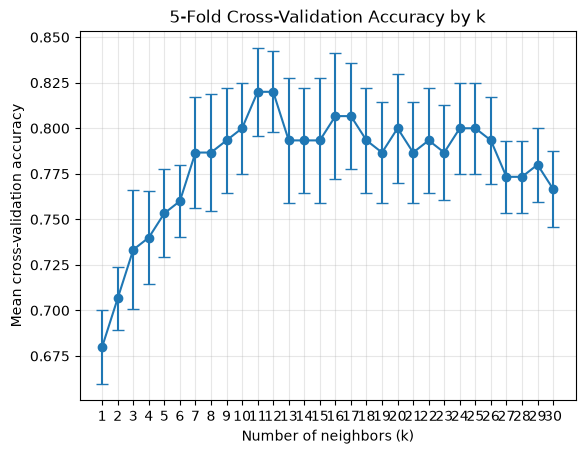

11
0.82


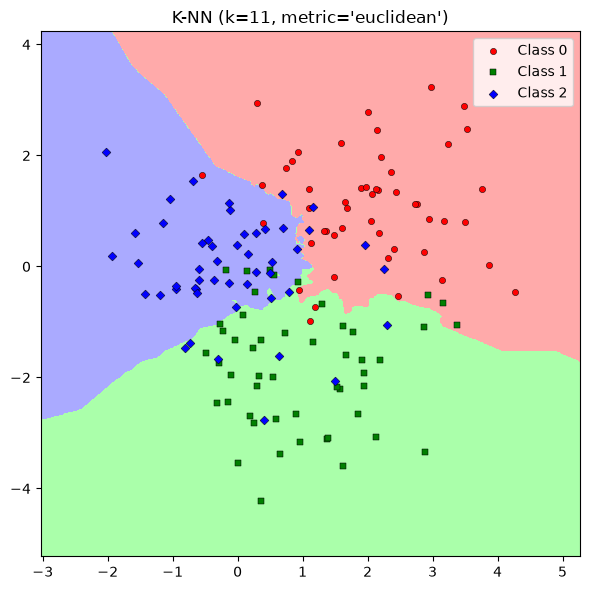

In [80]:
##❓YOUR CODE HERE
def evaluate_knn(X, y, ks, metric):
  # Write a function to fit the K-NN classifier and evaluate accuracy using 5-fold cross-validation
  # use random_state = 12 for the cross-validation
  ##❓YOUR CODE HERE
  crossVal = KFold(n_splits=5, shuffle=True, random_state=12)
  accuracy_scores = {}

  # loop through different values of k to run cross-validation on each
  for k in ks:
    model = KNeighborsClassifier(n_neighbors=k, metric=metric)
    scores = cross_val_score(model, X, y, cv=crossVal, scoring="accuracy")
    accuracy_scores[k] = scores

  # return classification accuracy scores from the cross-validation
  return accuracy_scores

# choose a distance metric
metric = "euclidean"
# apply the above function for your chosen distance metric
accuracy_scores = evaluate_knn(X, y, ks, metric)

# calculate mean and std error of accuracy across the 5 folds of cross-validation
mean_accuracies = [np.mean(accuracy_scores[k]) for k in ks]
sem_accuracies = [np.std(accuracy_scores[k]) for k in ks]/np.sqrt(5)

# Plot accuracy with error bars for each value of k
##❓YOUR CODE HERE
plt.errorbar(ks,
             mean_accuracies,
             yerr=sem_accuracies,
             marker="o",
             capsize=4)
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Mean cross-validation accuracy")
plt.title("5-Fold Cross-Validation Accuracy by k")
plt.xticks(list(ks))
plt.grid(True, alpha=0.3)
plt.show()



# find the best value of k and the corresponding accuracy
best_k = list(ks)[np.argmax(mean_accuracies)]
best_accuracy = np.max(mean_accuracies)
# make sure to print out the best value of k and corresponding accuracy
print(best_k)
print(best_accuracy)

# Plot decision boundaries for the best value of k (not all values of k!)
# the function from above is sufficient for this
plot_decision_boundaries_2(X, y, metric, best_k)

❓2.2.2 What is the best value of k for these data? Based on the plots of average cross-validation accuracy across various values of k, recommend and defend a range of appropriate values of k.

✅ Answer: The best value is k=11 (accuracy = 0.82). A reasonable range is k=9-13 because these values sit at or near the accuracy plateau, are all within one standard error of the peak, and avoid both the sharp underfitting drop-off at very low k and the slight decline in the high k=20s-30s range. Within that range, odd k (11 or 13) is preferable to even k (12) to avoid ties across the three classes.

## Section 3: tSNE! (PBMCs)

### 3.1: Load the Data and Manipulate

❓3.1.1 Load the provided file of scRNA-seq data as a pandas dataframe. Visualize just the first few rows and *and only the first few columns* of the data -- as described in the background document, there are thousands of cells (columns) in this dataset.

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# load local file "data_03_pbmcs.txt"
# from google.colab import files

# uploaded = files.upload()

# for fn in uploaded.keys():
  # print('User uploaded file "{name}" with length {length} bytes'.format(
      # name=fn, length=len(uploaded[fn])))

In [67]:
##❓YOUR CODE HERE
# load the pbmc data as a pandas df
pmbc = pd.read_csv("data_03_pbmc.txt", sep="\t")

# Look at the top of the data
# be careful to just look at the first few rows AND only the first few columns
pmbc.iloc[:5, :5]

,AAACATACAACCAC-1,AAACATTGAGCTAC-1,AAACATTGATCAGC-1,AAACCGTGCTTCCG-1,AAACCGTGTATGCG-1
PPBP,0.000000,0.000000,0.000000,1.566387,0.000000
LYZ,1.635873,1.962726,1.995416,4.521175,0.000000
S100A9,0.000000,0.000000,0.000000,3.838845,0.000000
IGLL5,0.000000,0.000000,0.000000,0.000000,0.000000
GNLY,0.000000,0.000000,1.429744,0.000000,3.453545


❓3.1.2 Transpose your loaded pandas df to make the observations (cells) into rows to make it compatible with `scikitlearn`.

In [68]:
##❓YOUR CODE HERE
print(pmbc.shape)

# transpose the pbmc df
pmbcTransposed = pmbc.T

# check that it's the size/shape you expect
print(pmbcTransposed.shape)

(2000, 2638)
(2638, 2000)


### 3.2: Make a t-SNE Plot

❓3.2.1 Use scikitlearn to make a t-SNE embeddings of these PBMCs.

In [69]:
from sklearn.manifold import TSNE
##❓YOUR CODE HERE
# make and display a t-SNE in 2 dimensions
# Create a t-SNE model in 2-D and fit it to the data
tsneEmbed = TSNE(n_components=2, random_state=42).fit_transform(pmbcTransposed)

❓3.2.2 Plot your embeddings! Since there are a lot of cells that will pile up on top of each other, be sure to adjust `alpha` to make the points a bit transparent and avoid overplotting.

Text(0, 0.5, 'TSNE 2')

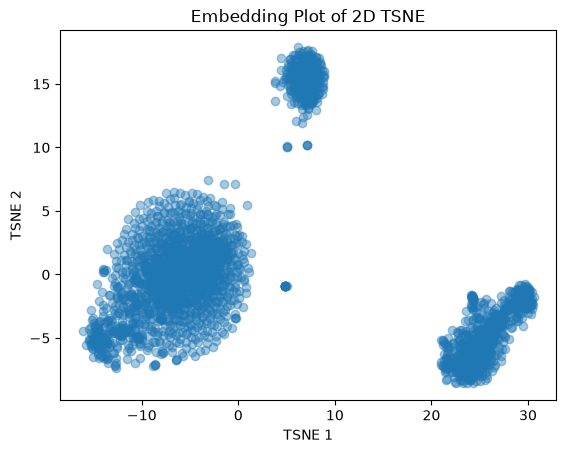

In [70]:
##❓YOUR CODE HERE
# Plot the t-SNE embedding
tsne1 = tsneEmbed[:, 0]
tsne2 = tsneEmbed[:, 1]

# Plot the t-SNE embedding
plt.scatter(tsne1, tsne2, alpha=0.4)
plt.title("Embedding Plot of 2D TSNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

### 3.3: Color the t-SNE Plot by Marker Gene Expressions

❓3.3.1 Remake the plot you made above, but color it by the expression (counts) of the marker genes on the list below (making 4 plots). Make sure to add a colorbar to each to understand the scale. Skeleton code is provided.


Marker genes:
- MS4A1
- PPBP
- LYZ
- CD14

2638
2638


/var/folders/bc/8499g6wj7vs5jrc1b4nr_nhw0000gn/T/ipykernel_27221/1830452837.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


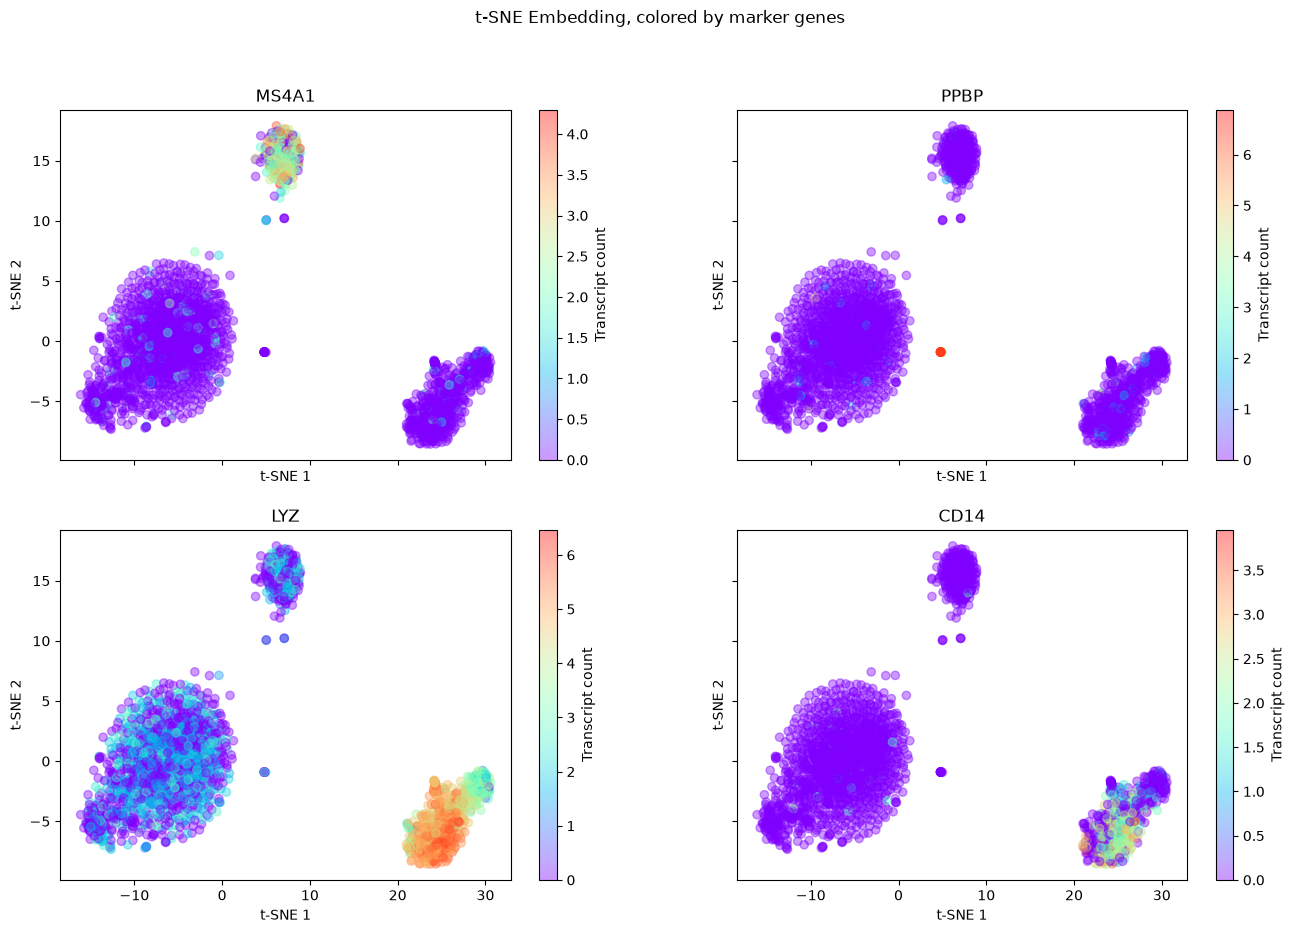

In [71]:
##❓YOUR CODE HERE
expression = pmbcTransposed["MS4A1"]
print(len(tsneEmbed))
print(len(expression))

# make the plot above, but colored by the marker genes
# remember to add a color bar for scale
# label the plots with the gene name

# Suggested skeleton for using map() for this task
 #(not necessary to use the skeleton, but it has helpful reminders)
# make a list of marker genes you'd like to plot
markers = ["MS4A1", "PPBP", "LYZ","CD14"]

# set up figure for plotting with subplots
fig, ax = plt.subplots(2,2,
                       sharex = True, 
                       sharey=True, 
                       figsize=(16,10))
fig.suptitle('t-SNE Embedding, colored by marker genes')
axes = [ax[0,0],
        ax[0,1],
        ax[1,0],
        ax[1,1]]

# write a function to put the marker gene into the appropriate subplot
def plot_my_gene(marker_gene, axis):
  ##❓YOUR CODE HERE
  expression = pmbcTransposed[marker_gene]
  points = axis.scatter(tsne1,
                        tsne2,
                        c=expression,
                        cmap="rainbow",
                        alpha=0.4)
  axis.set_title(marker_gene)
  axis.set_xlabel("t-SNE 1")
  axis.set_ylabel("t-SNE 2")

  # remember to add a colorbar
  fig.colorbar(points,
               ax=axis,
               label="Transcript count")

  # remember to label each plot
  axis.set_title(marker_gene)


# map the function across the list of marker genes and subplots
list(map(plot_my_gene, markers, axes))
# display the full figure
fig.show()

❓3.3.2 Looking at the plots above, **do you think the marker gene(s) do a good job differentiating the various celltypes present in this dataset? In particular, what is the PPBP plot showing?** Assume here that "cell type" refers to cells that are neighbors - we expect some transcriptional variation within a cell type, but cells within a particular cell type are generally similar and are neighbors in high-dimensional transcriptional "space."

*Please only give a couple sentences description as a brief answer.*

✅ Answer: The marker genes do a reasonable job overall. MS4A1 marks the small top cluster (B cells), while LYZ and CD14 together mark the bottom-right cluster (monocytes), with LYZ showing the sharper, more clearly separated signal. The large left cluster stays low across all four markers, which is expected since it likely contains T cells and NK cells that don't express B-cell or monocyte markers. PPBP is the exception and shows no cluster-specific enrichment at all, with expression near zero everywhere except a single isolated outlier; PPBP fails as a useful differentiator here.

### 3.4: Color tSNE by external labels
❓3.4.1 Run the codeblock below to load in the celltype labels, which are in the same order as the original columns of the PBMC dataframe. Plot your tSNE embeddings colored by the provided celltype labels.

In [72]:
# Load the celltype labels as a pd df
# uploaded = files.upload()

# for fn in uploaded.keys():
  # print('User uploaded file "{name}" with length {length} bytes'.format(
      # name=fn, length=len(uploaded[fn])))

pbmc_idents = pd.read_csv("data_04_pbmcidents.txt",
                          header=0,
                          sep = "\t",
                          quotechar = '"',
                          quoting = 0)
# check that we've got labels! (just have a look at the data)
pbmc_idents.head(10)

,ident
AAACATACAACCAC-1,Memory.CD4
AAACATTGAGCTAC-1,B
AAACATTGATCAGC-1,Memory.CD4
AAACCGTGCTTCCG-1,CD14.Mono
AAACCGTGTATGCG-1,NK
AAACGCACTGGTAC-1,Memory.CD4
AAACGCTGACCAGT-1,CD8.T
AAACGCTGGTTCTT-1,CD8.T
AAACGCTGTAGCCA-1,Naive.CD4.T
AAACGCTGTTTCTG-1,FCGR3A.Mono


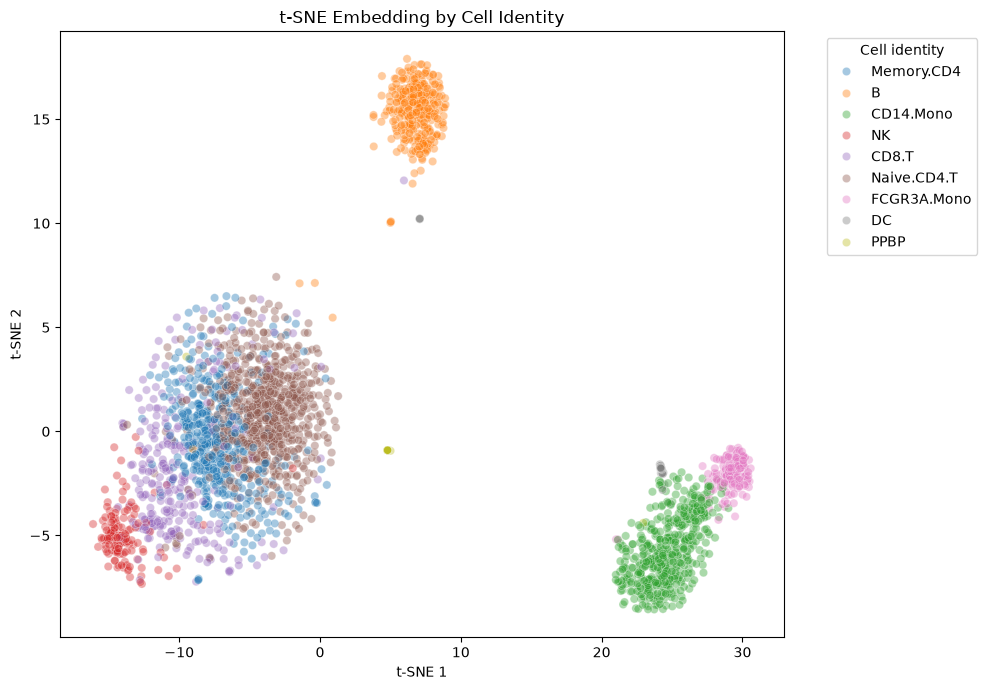

In [73]:
# import seaborn to make plotting easier with labels
import seaborn as sns
##❓YOUR CODE HERE
# first combine the tsne embeddings with the labels into 1 df
df = pd.DataFrame({"tsne1": tsne1,
                   "tsne2": tsne2,
                   "identity": pbmc_idents["ident"]})

# use seaborn to plot nicely and generate automatic labels of your celltypes
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df,
                x="tsne1",
                y="tsne2",
                hue="identity",
                alpha=0.4)
plt.title("t-SNE Embedding by Cell Identity")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cell identity",
           bbox_to_anchor=(1.05, 1),
           loc="upper left")
plt.tight_layout()
plt.show()

## ⭐ Bonus - Section 4: A Return to kNN - PBMCs

Now we're going to try using k-NN to group the PBMC data and compare the classifications kNN produces to the t-SNE embedding.

⭐ 4.1 Apply 8-NN to the pbmc dataset, randomly splitting the cells into 80% training and 20% test sets. Then plot the test data's tSNE embeddings and color 2 ways: the true cell identities and the **8-NN** assignments.

In [74]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split the dataset into train and test sets
indices = np.arange(pmbcTransposed.shape[0])
XTrain, XTest, yTrain, yTest, idxTrain, idxTest = train_test_split(
    pmbcTransposed,
    pbmc_idents["ident"],
    indices,
    test_size=0.2,
    random_state=42)

# recombine train and test to redo the t-SNE embeddings
XRecombined = pd.concat([XTrain, XTest])

# redo the tsne embeddings
# tsne embeddings must be done all together
tsneEmbed2 = TSNE(n_components=2, random_state=42).fit_transform(XRecombined)
nTrain = XTrain.shape[0]
tsneTrain = tsneEmbed2[:nTrain]
tsneTest = tsneEmbed2[nTrain:]

<function matplotlib.pyplot.show(close=None, block=None)>

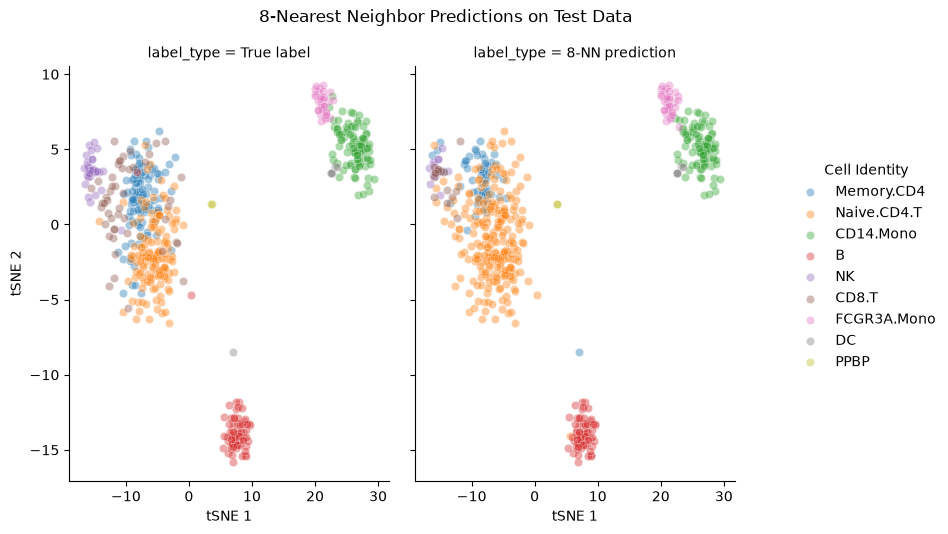

In [75]:
##❓YOUR CODE HERE

# Create a KNN classifier with 8 neighbors
knn8 = KNeighborsClassifier(n_neighbors=8)

# fit the model on the training data
knn8.fit(XTrain, yTrain)

# apply the model to make predictions on training and test data
yTrainPred = knn8.predict(XTrain)
yTestPred = knn8.predict(XTest)

# plot just the test data to visualize how well we did!
# make 2 subplots, one with the data colored by true identities
# the other colored by the predicted class labels
# however you plot, make sure to print a legend and appropriate titles
tsne_df_test = pd.concat([
    pd.DataFrame({
        "tsne1": tsneTest[:, 0],
        "tsne2": tsneTest[:, 1],
        "identity": yTest.values,
        "label_type": "True label"}),
    pd.DataFrame({
        "tsne1": tsneTest[:, 0],
        "tsne2": tsneTest[:, 1],
        "identity": yTestPred,
        "label_type": "8-NN prediction"})
])

# example to use seaborn to plot nicely and generate automatic labels of your celltypes
# change "tsne_df_test" to the appropriate pd dataframe
g = sns.FacetGrid(tsne_df_test, col="label_type", hue="identity")
g.map(sns.scatterplot, "tsne1","tsne2", alpha = 0.4)
g.set_axis_labels("tSNE 1","tSNE 2")
g.add_legend()
g.fig.suptitle("8-Nearest Neighbor Predictions on Test Data")
g.legend.set_title("Cell Identity")
g.figure.set_size_inches(10, 6)
plt.show

⭐ 4.2 Report the model accuracy to give an idea of how this 8-NN model does overall. Because we have several different cell identities and the model does not appear to perform equally well across all identities, also use the [`classification_report` function](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) to give a more detailed breakdown across cell types.

In [76]:
from sklearn.metrics import classification_report
##❓YOUR CODE HERE
# Evaluate the model on the test set
test_accuracy = accuracy_score(yTest, yTestPred)


# Suggestions for nice printing for TAs
print(f"Test accuracy: {test_accuracy:.2f}")


# print classification report
print(classification_report(yTest, yTestPred))

Test accuracy: 0.75
              precision    recall  f1-score   support

           B       1.00      0.96      0.98        71
   CD14.Mono       0.99      0.97      0.98       100
       CD8.T       0.33      0.10      0.16        48
          DC       1.00      0.83      0.91         6
 FCGR3A.Mono       0.91      0.97      0.94        33
  Memory.CD4       0.67      0.38      0.48       101
          NK       1.00      0.47      0.64        32
 Naive.CD4.T       0.57      0.99      0.72       135
        PPBP       1.00      1.00      1.00         2

    accuracy                           0.75       528
   macro avg       0.83      0.74      0.76       528
weighted avg       0.76      0.75      0.72       528



⭐4.3 Look back at your graph above. Do the model assignments match the provided labels on the data in general?  Briefly describe visual differences between the predicted and given cell identity classes. Are there particular clusters on which the 8-NN model appears to do better or worse? Do the t-SNE embeddings help explain why the model succeeds and fails at identifying in particular cell types?

🍓Answer: The 8-NN predictions match the true labels well for transcriptionally distinct populations. B, CD14.Mono, FCGR3A.Mono, DC, and PPBP all have F1 scores above 0.90, matching their relatively clean separation in the t-SNE plots. The model fails, however, on the T-cell subtypes. CD8.T and Memory.CD4 have only 10% and 38% recall, respectively, while Naive.CD4.T has 99% recall but 57% precision. This means the model systematically mislabels CD8.T and Memory.CD4 cells as Naive.CD4.T. This lines up with the t-SNE embedding where Memory.CD4, Naive.CD4.T, CD8.T, and NK all occupy the same overlapping region of the plot rather than forming distinct clusters. This shows similar transcriptional profiles among these T/NK lineage cells. Because kNN classifies by local majority, and Naive.CD4.T has the largest in this region, the points in the overlap zone tend to get pulled toward the numerically dominant class rather than their true label (leading to a class-imbalance).